***Выбранный датасет(Mall Customer Segmentation Data) содержит в себе информацию о 200 покупателях, участвующих в программе лояльности магазина.***


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
df = pd.read_csv('~/Downloads/Mall_Customers.csv')

**Датасет содержит информацию о поле, возрасте, годовом доходе в тысячах долларов и тратах покупателей (Spending Score - это баллы, которые магазин присвоил каждому клиенту на основе его поведения: частоты визитов, среднего чека, реакции на акции. Чем выше балл, тем больше и чаще покупатель тратит.)**

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum()) #пропусков нет, так как выводит ноль

   CustomerID  Gender  Age  Annual_Income  Spending_Score
0           1    Male   19             15              39
1           2    Male   21             15              81
2           3  Female   20             16               6
3           4  Female   23             16              77
4           5  Female   31             17              40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual_Income  Spending_Score
count  200.000000  200.000000     200.000000      200.000000
mean   100.500000   38.850000      60.560000       50.200000
st

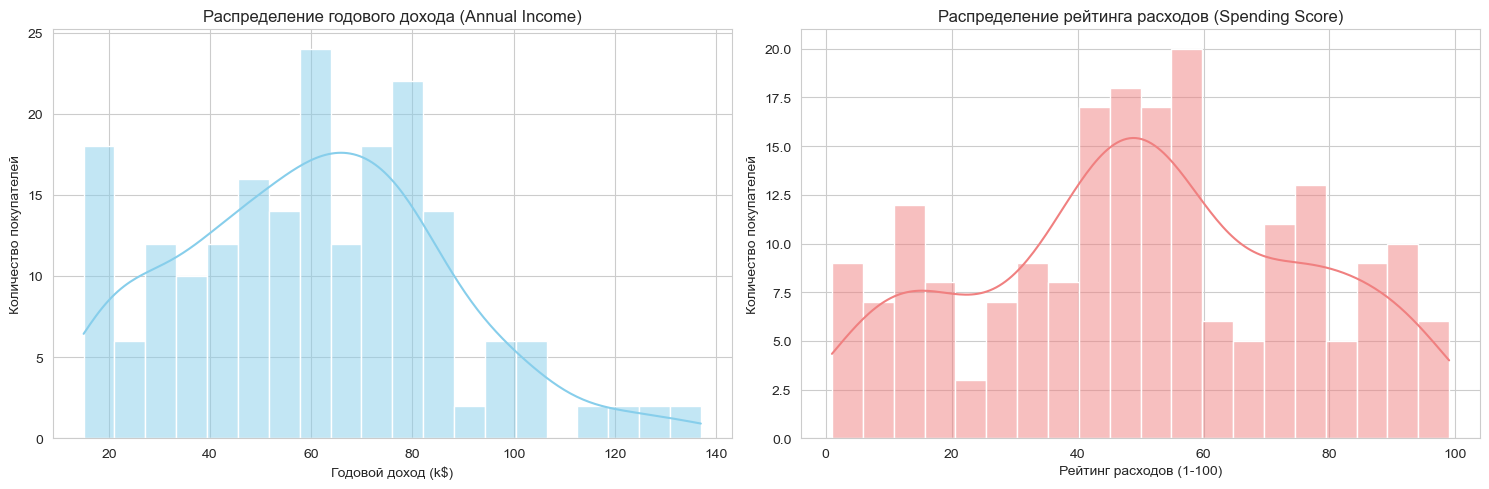

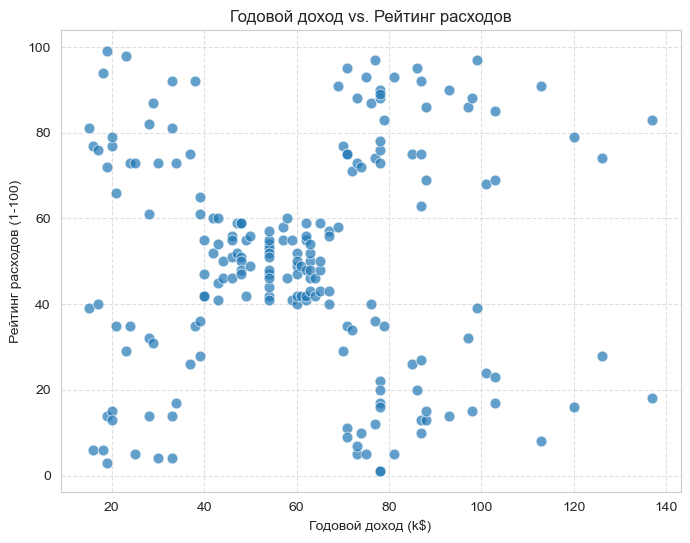

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Annual_Income'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение годового дохода (Annual Income)')
axes[0].set_xlabel('Годовой доход (k$)')
axes[0].set_ylabel('Количество покупателей')
sns.histplot(df['Spending_Score'], bins=20, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Распределение рейтинга расходов (Spending Score)')
axes[1].set_xlabel('Рейтинг расходов (1-100)')
axes[1].set_ylabel('Количество покупателей')

plt.tight_layout()
plt.show()

# Посмотрим на зависимость между доходом и расходами
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', s=60, alpha=0.7)
plt.title('Годовой доход vs. Рейтинг расходов')
plt.xlabel('Годовой доход (k$)')
plt.ylabel('Рейтинг расходов (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
features = ['Annual_Income', 'Spending_Score'] #Выбираем признаки для кластеризации (конечно же, только числовые)
X = df[features].copy()
#Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Исходные признаки: {features}")
print("Данные успешно отмасштабированы!")

Исходные признаки: ['Annual_Income', 'Spending_Score']
Данные успешно отмасштабированы!


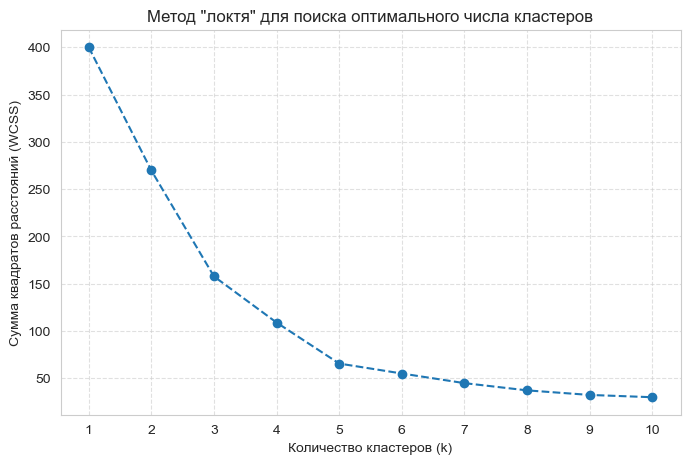

In [8]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
# Поиск оптимального числа кластеров с помощью метода локтя (Elbow method)
wcss = []  # Сюда будем сохранять сумму квадратов расстояний  
K_range = range(1, 11)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42) # Проверим от 1 до 10 кластеров
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Визуализируем метод "локтя"
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Метод "локтя" для поиска оптимального числа кластеров')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (WCSS)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Видим, что существенно уменьшаться наша дуга начинает при k = 5. Значит, оптимальнее всего разбить наших покупателей на 5 групп.**


In [9]:
#словарь с нашими моделями
models = {
    'K-Means (k=5)': KMeans(n_clusters=5, init='k-means++', random_state=42),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=5)
}

#список для сбора результатов
results_list = []

#применим каждую модель и оценим ее
for name, model in models.items():
    print(f"\nМОДЕЛЬ: {name}")
    # Обучаем модель
    labels = model.fit_predict(X_scaled)
    # Считаем количество кластеров
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0) #оставляем реальное чистое количество кластеров 
    n_noise = list(labels).count(-1)
    print(f"Найдено кластеров: {n_clusters}")
    if name == 'DBSCAN':
        print(f"Шумовых точек: {n_noise}")
    # Оцениваем качество, если кластеров больше 1 и не все точки шум
    if n_clusters > 1:
        sil_score = silhouette_score(X_scaled, labels)  #насколько каждый объект «похож» 
        #на другие объекты в том кластере, в который он был распределён в процессе кластеризации, и «не похож» на объекты из других кластеров
        ch_score = calinski_harabasz_score(X_scaled, labels) #Отношение разброса между кластерами к разбросу внутри кластеров.
        #Чем больше это отношение, тем лучше.
        db_score = davies_bouldin_score(X_scaled, labels) #Оценивает среднее сходство между каждым кластером и наиболее похожим на него кластером.

        print(f"Коэффициент силуэта (S): {sil_score:.4f}")
        print(f"Индекс Калински-Харабаса (CH): {ch_score:.2f}")
        print(f"Индекс Дэвиса-Болдина (DB): {db_score:.4f}")

        # Добавляем результат в список
        results_list.append({
            'Model': name,
            'Silhouette': sil_score,
            'Calinski-Harabasz': ch_score,
            'Davies-Bouldin': db_score
        })
    else:
        print("  - Недостаточно кластеров для расчета метрик")

# Превращаем список результатов в DataFrame
metrics_df = pd.DataFrame(results_list)

print("\nСводная таблица метрик")
print(metrics_df.to_string(index=False))


МОДЕЛЬ: K-Means (k=5)
Найдено кластеров: 5
Коэффициент силуэта (S): 0.5547
Индекс Калински-Харабаса (CH): 248.65
Индекс Дэвиса-Болдина (DB): 0.5722

МОДЕЛЬ: DBSCAN
Найдено кластеров: 2
Шумовых точек: 8
Коэффициент силуэта (S): 0.3504
Индекс Калински-Харабаса (CH): 60.84
Индекс Дэвиса-Болдина (DB): 0.8285

МОДЕЛЬ: Agglomerative
Найдено кластеров: 5
Коэффициент силуэта (S): 0.5538
Индекс Калински-Харабаса (CH): 244.41
Индекс Дэвиса-Болдина (DB): 0.5779

Сводная таблица метрик
        Model  Silhouette  Calinski-Harabasz  Davies-Bouldin
K-Means (k=5)    0.554657         248.649320        0.572236
       DBSCAN    0.350446          60.838816        0.828510
Agglomerative    0.553809         244.410326        0.577862


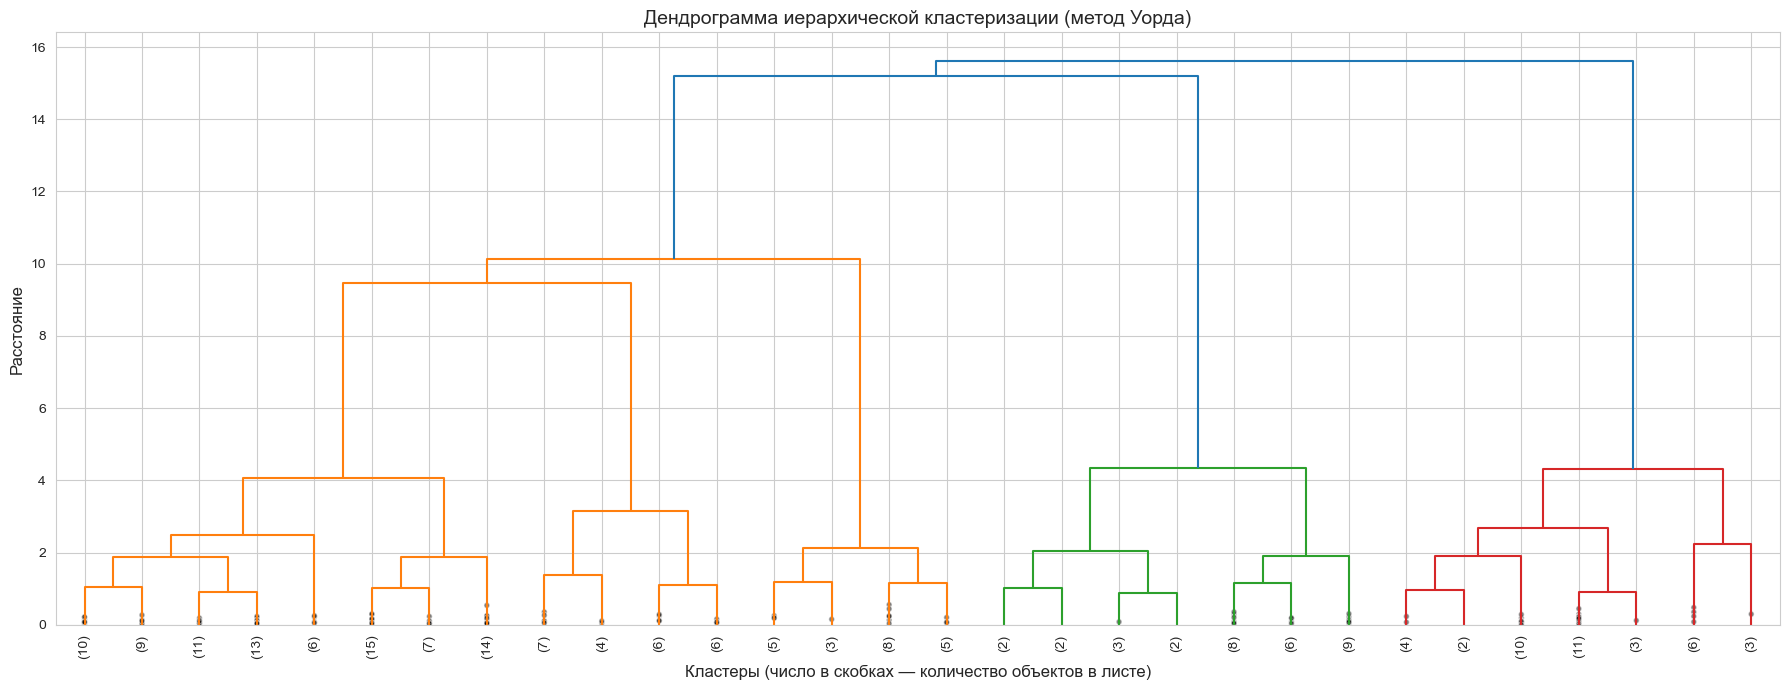

In [23]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
#строим матрицу связей
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(18, 7))

#Рисуем дендрограмму и СОХРАНЯЕМ результат в переменную, чтобы он не вывелся как текст
dendro = dendrogram(
    linked,
    truncate_mode='lastp',  # показываем только последние p ветвей
    p=30,                   # количество листьев
    show_contracted=True,   # показываем свернутые кластеры
    leaf_rotation=90.,      # вертикальные подписи
    leaf_font_size=10.,
    distance_sort='descending'
)
plt.title('Дендрограмма иерархической кластеризации (метод Уорда)', fontsize=14)
plt.xlabel('Кластеры (число в скобках — количество объектов в листе)', fontsize=12)
plt.ylabel('Расстояние', fontsize=12)
plt.tight_layout()
plt.show()

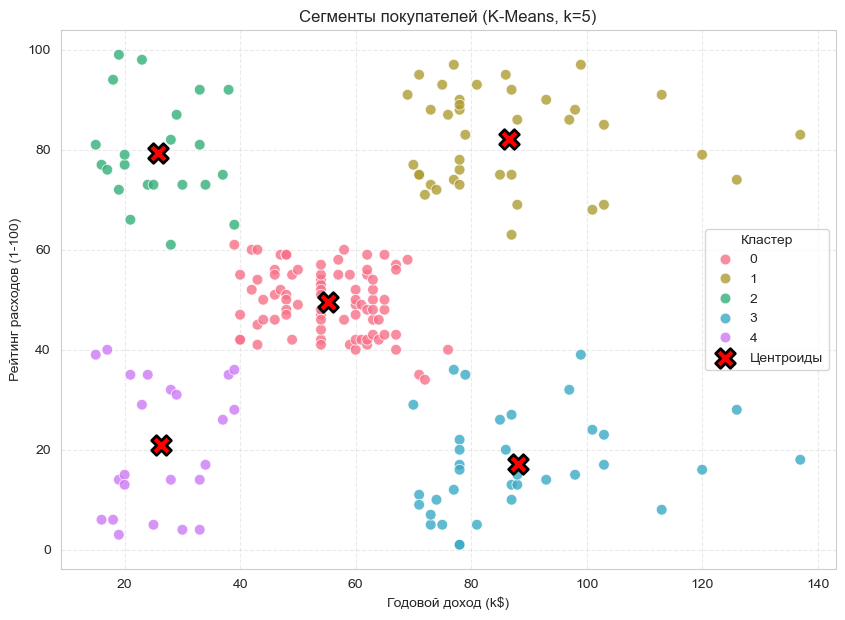


 Характеристики каждого кластера (средние значения)
           Age  Annual_Income  Spending_Score
Cluster                                      
0        42.72          55.30           49.52
1        32.69          86.54           82.13
2        25.27          25.73           79.36
3        41.11          88.20           17.11
4        45.22          26.30           20.91


In [26]:
# Применяем лучшую модель (K-Means)
best_model = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = best_model.fit_predict(X_scaled)
# Визуализируем кластеры
plt.figure(figsize=(10, 7))
# Используем палитру с 5 цветами
palette = sns.color_palette("husl", 5)
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Cluster', palette=palette, s=60, alpha=0.8)
# Добавим центроиды (центры кластеров)
centroids = scaler.inverse_transform(best_model.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Центроиды', edgecolors='black', linewidth=2)

plt.title('Сегменты покупателей (K-Means, k=5)')
plt.xlabel('Годовой доход (k$)')
plt.ylabel('Рейтинг расходов (1-100)')
plt.legend(title='Кластер')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Посмотрим на характеристики каждого кластера
print("\n Характеристики каждого кластера (средние значения)")
cluster_summary = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(2)
print(cluster_summary)

**ИТОГ РАБОТЫ**

Кластер 0: Клиенты с низким доходом и низкими тратами.

Кластер 1: Клиенты с низким доходом, но высокими тратами.

Кластер 2: Клиенты со средним доходом и средними тратами.

Кластер 3: Клиенты с высоким доходом и низкими тратами.

Кластер 4: Клиенты с высоким доходом и высокими тратами (самые ценные клиенты).

Распределение пола внутри каждого кластера (%):
Gender   Female  Male
Cluster              
0          59.3  40.7
1          53.8  46.2
2          59.1  40.9
3          45.7  54.3
4          60.9  39.1


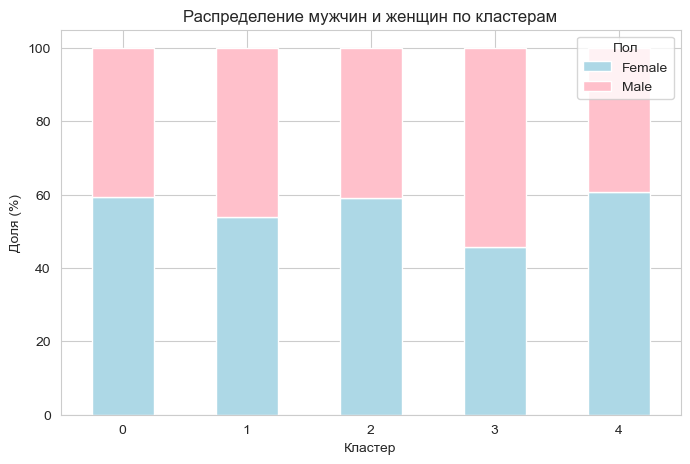

In [27]:
# Анализ распределения пола внутри кластеров (после того как мы нашли кластеры)
cluster_gender = pd.crosstab(df['Cluster'], df['Gender'], normalize='index') * 100

print("Распределение пола внутри каждого кластера (%):")
print(cluster_gender.round(1))

cluster_gender.plot(kind='bar', stacked=True, figsize=(8, 5), color=['lightblue', 'pink'])
plt.title('Распределение мужчин и женщин по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Доля (%)')
plt.legend(title='Пол')
plt.xticks(rotation=0)
plt.show()

**Как видно на дополнительном графике, пол не является определяющим фактором, ведь и мужчины, и женщины встречаются во всех пяти сегментах. Однако можно заметить, что в Кластере 1 (низкий доход, высокие траты) значительно преобладают женщины, а в Кластере 3 (высокий доход, низкие траты) — мужчины.**